11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0761 - val_loss: 0.0264
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0243 - val_loss: 0.0195
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0191 - val_loss: 0.0170
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0165 - val_loss: 0.0148
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0148 - val_loss: 0.0135
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0138 - val_loss: 0.0128
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0129 - val_loss: 0.0120
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0122 - val_loss: 0.0115
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0117 - val_loss: 0.0111
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0112 - val_loss: 0.0106
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


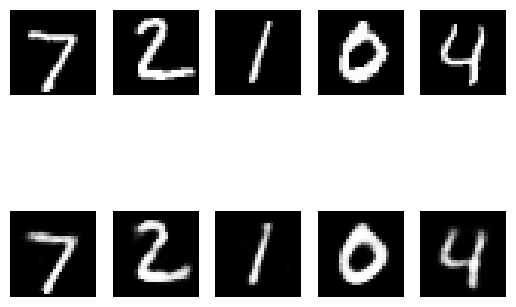

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# --- Cargar y preparar los datos ---
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0  # Normalizar a [0, 1]
x_test = x_test.astype('float32') / 255.0

# Redimensionar las imágenes a (28, 28, 1) para que sean compatibles con la red convolucional
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# --- Autoencoder ---
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Flatten()(input_img)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
encoded = layers.Dense(32, activation='relu')(x)

# Decoder
x = layers.Dense(64, activation='relu')(encoded)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(28 * 28, activation='sigmoid')(x)  # Para que los valores estén entre 0 y 1
decoded = layers.Reshape((28, 28, 1))(x)

# Crear el modelo autoencoder
autoencoder = models.Model(input_img, decoded)

# --- Compilación del modelo ---
autoencoder.compile(optimizer='adam', loss='mse')

# --- Entrenamiento ---
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

# --- Visualización de los resultados ---
def show_images(original, reconstructed, num_images=5):
    original = original[:num_images]
    reconstructed = reconstructed[:num_images]
    for i in range(num_images):
        plt.subplot(2, num_images, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.show()

# Ver imágenes originales y reconstruidas
reconstructed_images = autoencoder.predict(x_test)
show_images(x_test, reconstructed_images)
